# 다중 회귀와 예측 결과 분석

> 여러 입력 변수를 함께 사용해 더 정확한 회귀 모델을 만들고, 예측 결과를 깊이 있게 분석합니다.

| 구분 | 입력 변수 개수 | 예측식 |
| --- | --- | ---|
| 단순 회귀 | 1개 | `점수 = a x 공부시간 + b` |
| 다중 회귀 | 여러 개 | `점수 = a(1) x 공부시간 + a(2) x 출석률 + a(3) x 과제 점수 + b` |

-> 각 변수마다 자신의 계수(coef, 가중치)를 갖고, 모든 항을 더한 뒤 마지막 절편(interp_)을 더해 예측값을 만든다.

## 라이브러리 불러오기

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score

In [2]:
student_df = pd.DataFrame({
    # 하루 평균 공부 시간
    "study_hours": [1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10, 11],
    # 출석률
    "attendance": [50, 55, 60, 58, 65, 70, 72, 75, 78, 80, 82, 85, 88, 90, 92, 93, 95, 96, 97, 98],
    # 과제 점수
    "assignment": [40, 45, 50, 52, 55, 60, 63, 68, 70, 75, 78, 82, 85, 88, 90, 92, 94, 95, 96, 98],
    # 최종 시험 점수, 모델이 예측해야 할 값
    "score": [45, 50, 53, 56, 60, 64, 67, 70, 73, 76, 79, 82, 85, 88, 90, 92, 94, 95, 96, 98]
})

student_df.head()

,study_hours,attendance,assignment,score
0,1,50,40,45
1,2,55,45,50
2,2,60,50,53
3,3,58,52,56
4,3,65,55,60


## 데이터 살펴보기

In [3]:
student_df.describe()

,study_hours,attendance,assignment,score
count,20.000000,20.000000,20.000000,20.000000
mean,6.000000,78.950000,73.800000,75.650000
std,2.991215,15.226276,18.729656,16.828156
min,1.000000,50.000000,40.000000,45.000000
25%,3.750000,68.750000,58.750000,63.000000
50%,6.000000,81.000000,76.500000,77.500000
75%,8.250000,92.250000,90.500000,90.500000
max,11.000000,98.000000,98.000000,98.000000


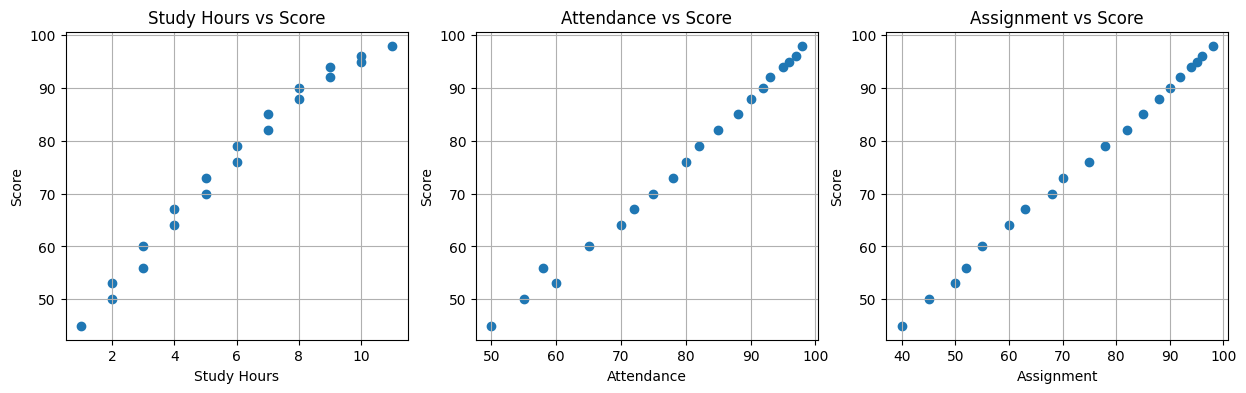

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(student_df["study_hours"], student_df["score"])
axes[0].set_title("Study Hours vs Score")
axes[0].set_xlabel("Study Hours")
axes[0].set_ylabel("Score")
axes[0].grid(True)

axes[1].scatter(student_df["attendance"], student_df["score"])
axes[1].set_title("Attendance vs Score")
axes[1].set_xlabel("Attendance")
axes[1].set_ylabel("Score")
axes[1].grid(True)

axes[2].scatter(student_df["assignment"], student_df["score"])
axes[2].set_title("Assignment vs Score")
axes[2].set_xlabel("Assignment")
axes[2].set_ylabel("Score")
axes[2].grid(True)

## 단순 회귀 모델 만들기 (비교용 베이스라인)

다중 회귀와 성능 비교 할 때 기준점(baseline)으로 사용

In [12]:
X = student_df[["study_hours"]]
y = student_df["score"]

print('X 모양:', X.shape)
print('y 모양:', y.shape)

X 모양: (20, 1)
y 모양: (20,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print('훈련 데이터 개수:', len(X_train))
print('테스트 데이터 개수:', len(X_test))

# 모델 학습
model = LinearRegression()
model.fit(X_train, y_train)

print('모델 학습 완료')
print(f'기울기: ${model.coef_[0]:.3f}')
print(f'절편: ${model.intercept_:.3f}')

# 예측 점수 = 기울기 x study_hours + 절편
y_pred = model.predict(X_test)
print('예측 완료')

훈련 데이터 개수: 14
테스트 데이터 개수: 6
모델 학습 완료
기울기: $5.393
절편: $43.858
예측 완료


## 다중 회귀 모델 학습하기

In [23]:
X_multi = student_df[["study_hours", "attendance", "assignment"]]
y_multi = student_df["score"]

print('X_multi 모양:', X_multi.shape)
print('y_multi 모양:', y_multi.shape)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.3, random_state=42)

# 모델 학습
multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_m)

print('다중 선형 회귀 모델 학습 완료')

X_multi 모양: (20, 3)
y_multi 모양: (20,)
다중 선형 회귀 모델 학습 완료
